# Benchmark H2O Klasik — Full Range (0.20–5.80 Å)
### Perbandingan Kurva Energi Potensial (PES) O-H pada H₂O
**Metode:** HF, B3LYP, CASSCF(8,6), CASCI approx. (maxiter=1), FCI(10,7) — basis STO-3G

---
**Catatan metodologi:**
- Data merupakan **gabungan 2 range** Rigid Scan (Single Point/SP) dengan koordinat yang sama:
  `O(0,0,0), H(0,0,R), H(-0.8604, 0.2094, 0.3936)` (hasil optimasi Avogadro)
  - **Range 1:** R = 0.20–3.00 Å, 16 titik uniform
  - **Range 2:** R = 3.00–5.80 Å, 16 titik uniform
  - Titik R=3.00 Å hanya diambil dari Range 1 (tidak duplikasi).
- **FCI(10,7)** = CASSCF(nel=10, norb=7)/STO-3G → referensi eksak dalam basis STO-3G.
- **CASCI approx.** menggunakan `maxiter=1` (bukan CASCI murni karena `maxiter=0` menyebabkan I/O error di ORCA 6.0.1).


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from ipywidgets import interact, FloatRangeSlider, VBox, HBox, Label
import ipywidgets as widgets
from IPython.display import display

## 1. Data Hasil Simulasi (ORCA, Relaxed Scan)

In [2]:
import numpy as np

# ═══════════════════════════════════════════════════════
# RANGE 1: R = 0.20–3.00 Å, 16 titik
# ═══════════════════════════════════════════════════════
R1 = [np.float64(0.2), np.float64(0.38666666666666666), np.float64(0.5733333333333333), np.float64(0.76), np.float64(0.9466666666666665), np.float64(1.1333333333333333), np.float64(1.3199999999999998), np.float64(1.5066666666666666), np.float64(1.6933333333333331), np.float64(1.8799999999999997), np.float64(2.0666666666666664), np.float64(2.2533333333333334), np.float64(2.44), np.float64(2.6266666666666665), np.float64(2.8133333333333335), np.float64(3.0)]

E_HF1     = [-65.735275501498, -72.70215564321, -74.337376631838, -74.786126526308, -74.896650936002, -74.895420608677, -74.854576412963, -74.801353387364, -74.746422105835, -74.695015235522, -74.649968489797, -74.612242153674, -74.581554088567, -74.557067199219, -74.537789704551, -74.522741366701]

E_DFT1    = [-66.043081275817, -73.010605153956, -74.645967862402, -75.098408057665, -75.218156277167, -75.230366815495, -75.205165113982, -75.168221178915, -75.129218266938, -75.092744504141, -75.06122928052, -75.035421784978, -75.014999824923, -74.99921361159, -74.987248525569, -74.978349015496]

E_CASSCF1 = [-65.757320098911, -72.734580452894, -74.377404524723, -74.833806109847, -74.954554727109, -74.967530015552, -74.945878256011, -74.917401070167, -74.892623342207, -74.875118637178, -74.864594967332, -74.858944646042, -74.856105443588, -74.854733680851, -74.854091639597, -74.853800879516]

E_CASCI1  = [-65.7570672663, -69.763432162567, -71.969541184849, -73.050181166408, -73.670618453598, -74.011412714248, -74.190627064914, -74.281543028687, -74.324358891706, -74.34087945133, -74.343128102772, -74.337820499044, -74.32874066706, -74.318043644529, -74.306954817147, -74.296148421311]

E_FCI1    = [-65.757353694391, -72.734614585688, -74.377456586121, -74.833847216012, -74.954584930755, -74.967554063772, -74.945898763863, -74.917419238376, -74.892639741124, -74.87513363249, -74.864608919457, -74.858957916566, -74.856118324517, -74.854746341513, -74.854104186321, -74.853813368661]

# ═══════════════════════════════════════════════════════
# RANGE 2: R = 3.00–5.80 Å, 16 titik
# ═══════════════════════════════════════════════════════
R2 = [np.float64(3.0), np.float64(3.1866666666666665), np.float64(3.373333333333333), np.float64(3.56), np.float64(3.7466666666666666), np.float64(3.933333333333333), np.float64(4.12), np.float64(4.306666666666667), np.float64(4.493333333333333), np.float64(4.68), np.float64(4.866666666666666), np.float64(5.053333333333333), np.float64(5.24), np.float64(5.426666666666666), np.float64(5.613333333333333), np.float64(5.8)]

E_HF2     = [-74.522741335425, -74.511025615074, -74.501870938705, -74.494647910807, -74.488860546872, -74.484146206714, -74.480224195092, -74.476884007591, -74.473987053838, -74.471422941534, -74.469122384289, -74.467028937947, -74.465108571875, -74.463333782714, -74.461684743731, -74.460146289424]

E_DFT2    = [-74.978349035693, -74.97181158553, -74.967052753684, -74.963618510205, -74.961155444478, -74.959375771587, -74.958044566464, -74.957016418424, -74.95620991563, -74.955566109252, -74.955037999623, -74.95459009683, -74.954194236378, -74.95383411912, -74.953501929942, -74.953193119852]

E_CASSCF2 = [-74.853800879561, -74.853673685229, -74.853619967175, -74.853598086866, -74.853589520413, -74.853586324794, -74.853585175362, -74.853584775695, -74.853584635491, -74.853584582274, -74.853584559208, -74.853584547937, -74.853584542228, -74.85358453937, -74.853584538008, -74.853584537416]

E_CASCI2  = [-74.296148421311, -74.285965953945, -74.276550394586, -74.267930711833, -74.260074810727, -74.252921925902, -74.246401565473, -74.240443776501, -74.234984044355, -74.229965081437, -74.225336979471, -74.221056608023, -74.217086751965, -74.213395233416, -74.209954120995, -74.206739059067]

E_FCI2    = [-74.853813368661, -74.853686145562, -74.853632413302, -74.853610531439, -74.853601967099, -74.853598758771, -74.853597608561, -74.853597208674, -74.853597068376, -74.853597015195, -74.853596992176, -74.853596980964, -74.853596975308, -74.853596972493, -74.85359697116, -74.853596970589]

# ═══════════════════════════════════════════════════════
# GABUNGKAN (skip R=3.00 dari Range 2, sudah ada di Range 1)
# ═══════════════════════════════════════════════════════
R         = R1 + R2[1:]
E_HF      = E_HF1     + E_HF2[1:]
E_DFT     = E_DFT1    + E_DFT2[1:]
E_CASSCF  = E_CASSCF1 + E_CASSCF2[1:]
E_CASCI   = E_CASCI1  + E_CASCI2[1:]
E_FCI     = E_FCI1    + E_FCI2[1:]

print(f'Total titik R: {len(R)} ({R[0]:.2f} – {R[-1]:.2f} Å)')


Total titik R: 31 (0.20 – 5.80 Å)


## 2. Hitung Error Relatif

Referensi: **FCI(10,7)** — energi eksak dalam basis set STO-3G.


In [3]:
# ── Referensi: FCI ──
e_ref        = np.array(E_FCI)
error_hf     = np.abs(np.array(E_HF)     - e_ref)
error_dft    = np.abs(np.array(E_DFT)    - e_ref)
error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
error_casci  = np.abs(np.array(E_CASCI)  - e_ref)

CA = 0.0016  # Chemical Accuracy (Hartree)

idx_fci = E_FCI.index(min(E_FCI))

print(f'R_eq (FCI) = {R[idx_fci]:.2f} Å | E = {E_FCI[idx_fci]:.6f} Ha')
print(f'Mean |ΔE| HF     vs FCI = {np.mean(error_hf):.6e} Ha')
print(f'Mean |ΔE| B3LYP  vs FCI = {np.mean(error_dft):.6e} Ha')
print(f'Mean |ΔE| CASSCF vs FCI = {np.mean(error_casscf):.6e} Ha')
print(f'Mean |ΔE| CASCI  vs FCI = {np.mean(error_casci):.6e} Ha')


R_eq (FCI) = 1.13 Å | E = -74.967554 Ha
Mean |ΔE| HF     vs FCI = 2.619910e-01 Ha
Mean |ΔE| B3LYP  vs FCI = 1.641822e-01 Ha
Mean |ΔE| CASSCF vs FCI = 1.772840e-05 Ha
Mean |ΔE| CASCI  vs FCI = 7.846338e-01 Ha


## 3. Plot Kurva Energi Potensial (PES) dan Error


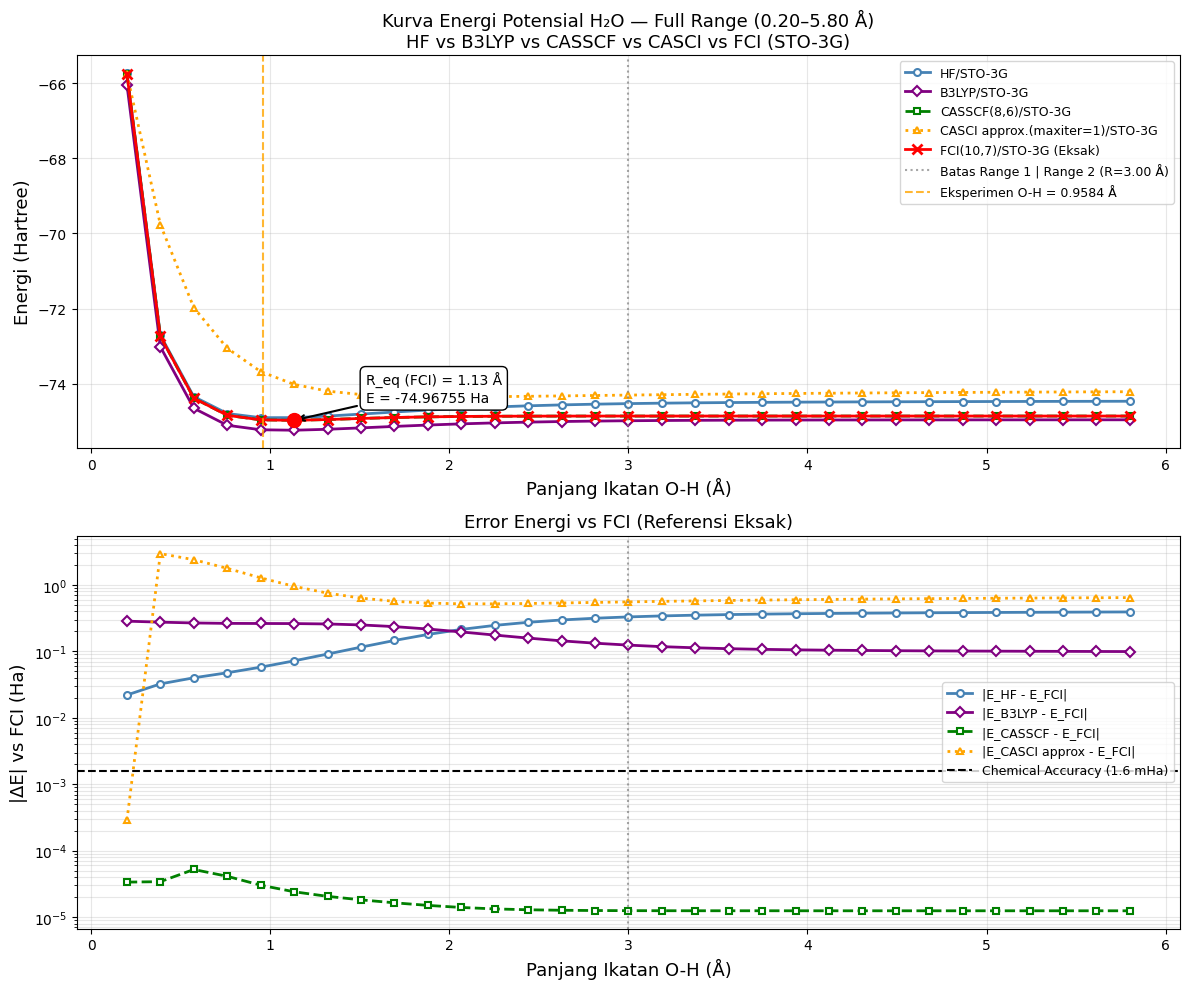

In [ ]:
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ── Plot 1: PES Full Range ──
ax1.plot(R, E_HF,    'o-',  color='steelblue', linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='HF/STO-3G')
ax1.plot(R, E_DFT,   'D-',  color='purple',    linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='B3LYP/STO-3G')
ax1.plot(R, E_CASSCF,'s--', color='green',     linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='CASSCF(8,6)/STO-3G')
ax1.plot(R, E_CASCI, '^:',  color='orange',    linewidth=2,
         markersize=5, markerfacecolor='white', markeredgewidth=1.5,
         label='CASCI approx.(maxiter=1)/STO-3G')
ax1.plot(R, E_FCI,   'x-',  color='red',       linewidth=2,
         markersize=7, markeredgewidth=2,
         label='FCI(10,7)/STO-3G (Eksak)')

ax1.plot(R[idx_fci], E_FCI[idx_fci], 'ro', markersize=10, zorder=5)
ax1.annotate(f'R_eq (FCI) = {R[idx_fci]:.2f} Å\nE = {E_FCI[idx_fci]:.5f} Ha',
             xy=(R[idx_fci], E_FCI[idx_fci]),
             xytext=(R[idx_fci]+0.4, E_FCI[idx_fci]+0.5),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                       edgecolor='black', linewidth=1))

ax1.axvline(x=3.00, color='gray', linestyle=':', linewidth=1.5, alpha=0.7,
            label='Batas Range 1 | Range 2 (R=3.00 Å)')
ax1.axvline(x=0.9584, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Eksperimen O-H = 0.9584 Å')
ax1.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax1.set_ylabel('Energi (Hartree)', fontsize=13)
ax1.set_title('Kurva Energi Potensial H₂O — Full Range (0.20–5.80 Å)\n'
              'HF vs B3LYP vs CASSCF vs CASCI vs FCI (STO-3G)',
              fontsize=13)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
# zoom manual — tinggal ganti angkanya
ax1.set_xlim(1.0, 3.0)  # zoom ke region yg km mau

# ── Plot 2: Error vs FCI ──
ax2.semilogy(R, error_hf     + 1e-10, 'o-',  color='steelblue', linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_HF - E_FCI|')
ax2.semilogy(R, error_dft    + 1e-10, 'D-',  color='purple',    linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_B3LYP - E_FCI|')
ax2.semilogy(R, error_casscf + 1e-10, 's--', color='green',     linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_CASSCF - E_FCI|')
ax2.semilogy(R, error_casci  + 1e-10, '^:',  color='orange',    linewidth=2,
             markersize=5, markerfacecolor='white', markeredgewidth=1.5,
             label='|E_CASCI approx - E_FCI|')
ax2.axhline(y=CA, color='black', linestyle='--',
            linewidth=1.5, label='Chemical Accuracy (1.6 mHa)')
ax2.axvline(x=3.00, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Panjang Ikatan O-H (Å)', fontsize=13)
ax2.set_ylabel('|ΔE| vs FCI (Ha)', fontsize=13)
ax2.set_title('Error Energi vs FCI (Referensi Eksak)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(1.0, 3.0)  # sinkron kedua plot

plt.tight_layout()
plt.savefig('PES_H2O_full_0.2to5.8.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Ringkasan Energi Elektronik ──
print('='*70)
print('RINGKASAN ENERGI ELEKTRONIK H₂O (STO-3G), Full Range 0.20–5.80 Å')
print('='*70)
print(f'{"Metode":<22} {"E_min (Ha)":>15} {"R_eq (Å)":>10} {"E(5.80 Å)":>14}')
print('-'*70)
datasets = {
    'HF':            E_HF,
    'B3LYP':         E_DFT,
    'CASSCF(8,6)':   E_CASSCF,
    'CASCI approx.': E_CASCI,
    'FCI(10,7)':     E_FCI,
}
for nama, E in datasets.items():
    idx = E.index(min(E))
    print(f'{nama:<22} {E[idx]:>15.6f} {R[idx]:>10.2f} {E[-1]:>14.6f}')
print('='*70)


RINGKASAN ENERGI ELEKTRONIK H₂O (STO-3G), Full Range 0.20–5.80 Å
Metode                      E_min (Ha)   R_eq (Å)      E(5.80 Å)
----------------------------------------------------------------------
HF                          -74.896651       0.95     -74.460146
B3LYP                       -75.230367       1.13     -74.953193
CASSCF(8,6)                 -74.967530       1.13     -74.853585
CASCI approx.               -74.343128       2.07     -74.206739
FCI(10,7)                   -74.967554       1.13     -74.853597
